# Lab: Evaluating Random Forest Performance

---

In this lab we will re-visit the California Housing dataset that we used in our [Regression Trees Lab](../03_non-linear_and_ensemble_models/13_regression_trees_lab.ipynb) but this time we'll focus on evaluating the performance the model using more metrics and visualization techniques.

Let's start by importing the necessary libraries, loading the California Housing dataset, and preparing it for the modeling.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew

In [3]:
# Load the dataset
data = fetch_california_housing()
X, y = data.data, data.target

In [4]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

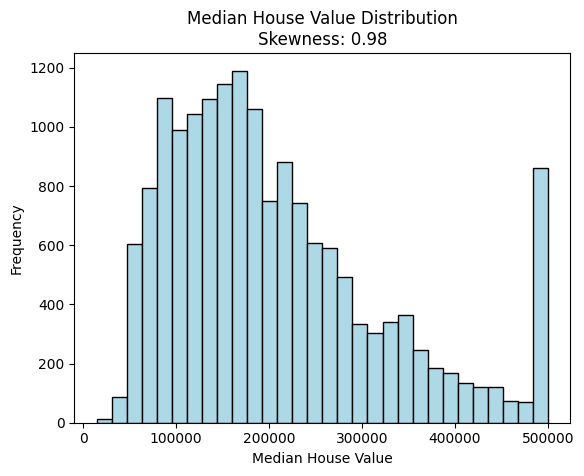

In [11]:
# Let's remember that the medan house prices are skewed. We can visualize this using a histogram.
plt.hist(1e5*y_train, bins=30, color='lightblue', edgecolor='black')
plt.title(f'Median House Value Distribution\nSkewness: {skew(y_train):.2f}')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

In [8]:
# Initialize and fit the Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Predict on test set
y_pred_test = rf_regressor.predict(X_test)

In [13]:
# Median house value as a reference point
median_house_value = np.median(y_train)
print(f'Median House Value: {median_house_value*1e5:.2f}\n')

# Calculate and print evaluation metrics
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = root_mean_squared_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Median House Value: 179850.00

Mean Absolute Error (MAE): 0.3276
Mean Squared Error (MSE): 0.2557
Root Mean Squared Error (RMSE): 0.5057
R² Score: 0.8049


📌 At this point we can say that "Around 80.5% of the variance in the median house values can be explained by the features in the dataset", as indicated by the R² score of 0.8049. We can also say that, on average, predicted median house prices are off by $33k, which is around 18% of the median house value. However, the big difference between the RMSE and MAE indicates that there are some larger errors that are affecting the RMSE more significantly. That's exactly why these statements alone are not enough to evaluate our model. We need visualization techniques to better understand where our model is performing well and where it is struggling. 